In [16]:
import tensorflow as tf
import os
# Change this path to go one level deeper into the 'train' folder
data_dir = "AcneDataset/train" 

# Standard parameters
batch_size = 32
img_height = 256
img_width = 256

# Load the Training set (Now it will see 'Blackheads', 'Cysts', etc.)
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='categorical'
)

# Load the Validation set from the same folder
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='categorical'
)

print(f"Corrected Classes: {train_ds.class_names}")


Found 2778 files belonging to 5 classes.
Using 2223 files for training.
Found 2778 files belonging to 5 classes.
Using 555 files for validation.
Corrected Classes: ['Blackheads', 'Cyst', 'Papules', 'Pustules', 'Whiteheads']


In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def create_acne_augmentation_pipeline():
    return keras.Sequential([
        # --- Geometric Augmentations ---
        layers.RandomFlip("horizontal"), 
        layers.RandomRotation(0.15, fill_mode='nearest'),
        layers.RandomZoom(0.1, fill_mode='nearest'),
        layers.RandomTranslation(0.1, 0.1, fill_mode='nearest'),
        
        # --- Photometric Augmentations ---
        # We remove value_range so it adapts to MobileNet's [-1, 1] automatically
        layers.RandomBrightness(0.15), 
        layers.RandomContrast(0.15),
        
    ])

# Initialize it
data_augmentation = create_acne_augmentation_pipeline()

In [18]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models


# --- 2. LOAD BASE MODEL ---
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(256, 256, 3),
    include_top=False, 
    weights='imagenet'
)
base_model.trainable = False

# --- 3. CREATE FULL MODEL ---
inputs = tf.keras.Input(shape=(256, 256, 3))

# Best Practice: Augment raw pixels (0-255) then Preprocess to (-1 to 1)
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False) 

# Stability layers
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Feature extraction head
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(len(train_ds.class_names), activation='softmax')(x)

model_v2 = tf.keras.Model(inputs, outputs)

# --- 4. COMPILE ---
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# --- 5. VERIFICATION ---
model_v2.summary()

print("\n" + "="*50)
print("MODEL VERIFICATION")
print("="*50)
print(f"✓ Base model frozen: {not base_model.trainable}")
print(f"✓ Number of classes: {len(train_ds.class_names)}")
print(f"✓ Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model_v2.trainable_weights]):,}")

C:\Users\saini\AppData\Local\Temp\ipykernel_18324\3514618441.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)          │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_6 (Sequential)            │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_4 (TrueDivide)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_4 (Subtract)                │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 8, 8, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 8, 8, 1280)          │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,433,349 (9.28 MB)

 Trainable params: 169,989 (664.02 KB)

 Non-trainable params: 2,263,360 (8.63 MB)


MODEL VERIFICATION
✓ Base model frozen: True
✓ Number of classes: 5
✓ Trainable parameters: 169,989


In [19]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_acne_model_stage1.keras',
        monitor='val_accuracy',
        save_best_only=True
    ),
    # MOST IMPORTANT ADDITION:
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

In [20]:
# Launch Stage 1
history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.4579 - loss: 1.5509 - precision: 0.5164 - recall: 0.3752 - val_accuracy: 0.4775 - val_loss: 1.3137 - val_precision: 0.5764 - val_recall: 0.3604 - learning_rate: 0.0010
Epoch 2/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.5776 - loss: 1.1161 - precision: 0.6528 - recall: 0.4854 - val_accuracy: 0.5946 - val_loss: 1.0424 - val_precision: 0.6848 - val_recall: 0.4541 - learning_rate: 0.0010
Epoch 3/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.6311 - loss: 0.9653 - precision: 0.7221 - recall: 0.5434 - val_accuracy: 0.5928 - val_loss: 1.0297 - val_precision: 0.6651 - val_recall: 0.5117 - learning_rate: 0.0010
Epoch 4/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.6653 - loss: 0.9017 - precision: 0.7335 - recall: 0.5560 - val_accuracy: 0.5982 - val_loss: 1.0978 - val_precision: 0.6532 - val_recall: 0.5225 - learning_rate: 0.0010
Epoch 5/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6645 

In [21]:
# 1. Unfreeze the base model
base_model.trainable = True

# 2. We ONLY want to fine-tune the top layers of MobileNetV2
# MobileNetV2 has 154 layers. we will freeze everything EXCEPT the last 54.
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. CRITICAL: Use a MUCH smaller learning rate (10x smaller)
# This prevents the model from "shattering" the pre-trained knowledge
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

# 4. Continue training for another 10-15 epochs
history_fine = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25, # Start from where we left off
    initial_epoch=history_v2.epoch[-1],
    callbacks=callbacks
)

Epoch 8/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.5744 - loss: 1.1551 - precision: 0.6407 - recall: 0.4773 - val_accuracy: 0.5766 - val_loss: 1.2049 - val_precision: 0.6008 - val_recall: 0.5369 - learning_rate: 1.0000e-04
Epoch 9/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6580 - loss: 0.8545 - precision: 0.7202 - recall: 0.5738  
Epoch 9: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
70/70 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.6640 - loss: 0.8617 - precision: 0.7297 - recall: 0.5794 - val_accuracy: 0.6126 - val_loss: 1.1825 - val_precision: 0.6233 - val_recall: 0.5784 - learning_rate: 1.0000e-04
Epoch 10/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.7036 - loss: 0.7598 - precision: 0.7712 - recall: 0.6415 - val_accuracy: 0.5892 - val_loss: 1.4551 - val_precision: 0.5985 - val_recall: 0.5694 - learning_rate: 5.0000e-05
Epoch 11/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7372 - loss: 0.6895 - precision: 0.80

In [22]:
# 1. Unfreeze the entire MobileNetV2 base
base_model.trainable = True

# 2. Re-freeze almost everything EXCEPT the very top layers
# This protects the early features (lines/colors) while tuning the complex ones (acne types)
for layer in base_model.layers[:-30]:
    layer.trainable = False

# 3. Compile with a much SMALLER learning rate
# High learning rates here will 'break' the pre-trained weights
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [23]:
# Resume training from where epoch 12 left off
history_fine = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    initial_epoch=history_v2.epoch[-1],
    callbacks=callbacks
)

Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.6572 - loss: 0.9163 - precision_1: 0.7203 - recall_1: 0.5722 - val_accuracy: 0.5622 - val_loss: 1.2850 - val_precision_1: 0.5774 - val_recall_1: 0.5243 - learning_rate: 1.0000e-05
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6627 - loss: 0.9008 - precision_1: 0.7267 - recall_1: 0.5709  
Epoch 9: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
70/70 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.6604 - loss: 0.8840 - precision_1: 0.7316 - recall_1: 0.5677 - val_accuracy: 0.5586 - val_loss: 1.3211 - val_precision_1: 0.5802 - val_recall_1: 0.5279 - learning_rate: 1.0000e-05
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.6572 - loss: 0.8543 - precision_1: 0.7303 - recall_1: 0.5762 - val_accuracy: 0.5676 - val_loss: 1.3116 - val_precision_1: 0.5789 - val_recall_1: 0.5351 - learning_rate: 5.0000e-06
Epoch 11/20
13/70 ━━━━━━━━━━━━━━━━━━━━ 1:17 1s/step - accuracy: 0.6810 - 

KeyboardInterrupt: 

In [24]:
model_v2.load_weights('best_acne_model_stage1.keras')
print("✅ Success: Restored the best weights from Stage 1!")

✅ Success: Restored the best weights from Stage 1!


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 86 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [25]:
# Unfreeze only the last 20 layers (more stable than unfreezing everything)
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Use an even smaller learning rate to prevent the "dip" in accuracy
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6), 
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [26]:
# This will run until it either hits 30 epochs or stops improving
history_overnight = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30, 
    callbacks=callbacks
)

# Final save just in case
model_v2.save('final_acne_model_morning.keras')

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.5996 - loss: 1.0469 - precision_2: 0.6590 - recall_2: 0.5173 - val_accuracy: 0.6324 - val_loss: 1.0023 - val_precision_2: 0.6858 - val_recall_2: 0.5820 - learning_rate: 5.0000e-06
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.6149 - loss: 1.0203 - precision_2: 0.6776 - recall_2: 0.5277 - val_accuracy: 0.6108 - val_loss: 1.0503 - val_precision_2: 0.6605 - val_recall_2: 0.5748 - learning_rate: 5.0000e-06
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6272 - loss: 0.9700 - precision_2: 0.6909 - recall_2: 0.5393  
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
70/70 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.6293 - loss: 0.9768 - precision_2: 0.6944 - recall_2: 0.5488 - val_accuracy: 0.6090 - val_loss: 1.0721 - val_precision_2: 0.6564 - val_recall_2: 0.5784 - learning_rate: 5.0000e-06
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.6392 - lo

In [27]:
'''If the matrix shows that the model correctly identifies Blackheads 90% of the time but fails on Cysts, we can apply Class Weights.
This tells the model: "Hey, pay 5x more attention to the Cysts because you keep getting them wrong"'''

'If the matrix shows that the model correctly identifies Blackheads 90% of the time but fails on Cysts, we can apply Class Weights.\nThis tells the model: "Hey, pay 5x more attention to the Cysts because you keep getting them wrong"'

Generating predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 882ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 878ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 886ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 868ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 887ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 908ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 911ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 907ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 904ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 895ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 914ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 925ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


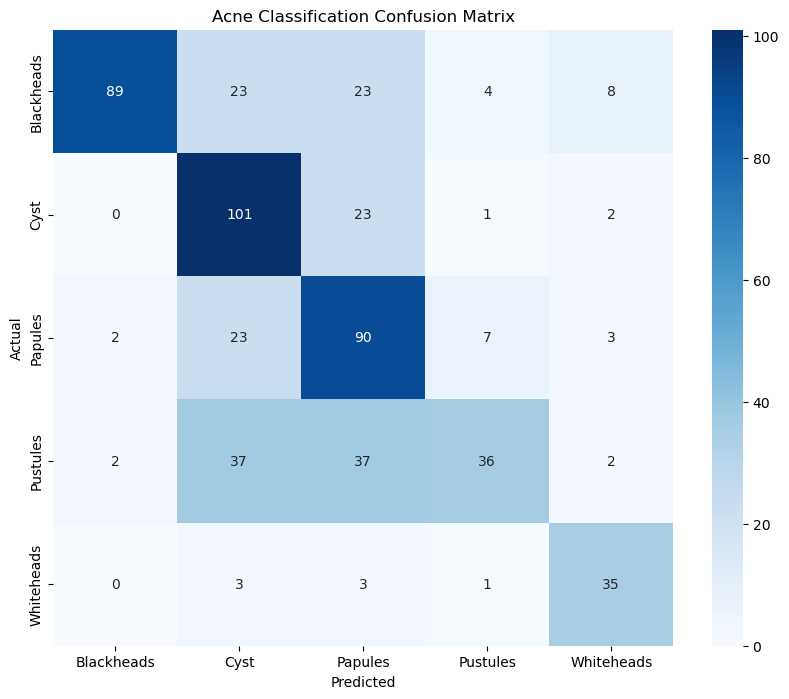

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predictions for the entire validation set
print("Generating predictions...")
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_v2.predict(images)
    y_true.extend(np.argmax(labels, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Create the matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.class_names,
            yticklabels=train_ds.class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Acne Classification Confusion Matrix')
plt.show()

In [29]:
'''✔ Strong classes: Cyst, Papules, Whiteheads
❌ Weak class: Pustules
⚠ High confusion between:

Papules ↔ Cyst

Pustules ↔ Papules/Cyst✔ Strong classes: Cyst, Papules, Whiteheads
❌ Weak class: Pustules
⚠ High confusion between:

Papules ↔ Cyst

Pustules ↔ Papules/Cyst'''
'''A confusion matrix compares:

Actual labels (ground truth) → rows

Predicted labels (model output) → columns

It tells us where the model is correct and where it gets confused.'''

'A confusion matrix compares:\n\nActual labels (ground truth) → rows\n\nPredicted labels (model output) → columns\n\nIt tells us where the model is correct and where it gets confused.'

In [30]:
'''The reason for this confusion is usually that the model doesn't have enough distinct examples of Pustules, 
or they look too similar to the other two red, inflamed acne types.
Since you've already done fine-tuning, the best way to fix this without needing new data is to use Class Weights.
This tells the model: "If you miss a Pustule, I'm going to penalize you 3x more than if you miss a Blackhead".'''

'The reason for this confusion is usually that the model doesn\'t have enough distinct examples of Pustules, \nor they look too similar to the other two red, inflamed acne types.\nSince you\'ve already done fine-tuning, the best way to fix this without needing new data is to use Class Weights.\nThis tells the model: "If you miss a Pustule, I\'m going to penalize you 3x more than if you miss a Blackhead".'

In [31]:
from sklearn.utils import class_weight
import numpy as np

# 1. Calculate weights based on your training data
# This gives more 'importance' to classes the model is failing (like Pustules)
class_indices = train_ds.class_names
labels_count = [len(os.listdir(f"AcneDataset/train/{c}")) for c in class_indices]
total = sum(labels_count)

# Custom weights: We manually boost Pustules because the matrix shows they are the weakest
# 0: Blackheads, 1: Cyst, 2: Papules, 3: Pustules, 4: Whiteheads
custom_weights = {0: 1.0, 1: 1.5, 2: 1.5, 3: 4.0, 4: 1.0} 

print("Applying extra focus to Pustules (Weight: 4.0)")

# 2. Final 'Polishing' Run
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6), # Ultra-small for polishing
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_final = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=custom_weights, # <--- The Magic Fix
    callbacks=callbacks
)

Applying extra focus to Pustules (Weight: 4.0)
Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.6208 - loss: 1.9914 - val_accuracy: 0.6144 - val_loss: 1.0399 - learning_rate: 1.0000e-06
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5945 - loss: 2.0099  
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999987376214e-07.
70/70 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.5938 - loss: 2.0523 - val_accuracy: 0.5964 - val_loss: 1.0753 - learning_rate: 1.0000e-06
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.6167 - loss: 1.9715 - val_accuracy: 0.5928 - val_loss: 1.0888 - learning_rate: 5.0000e-07
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6188 - loss: 2.0475  
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999993688107e-07.
70/70 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.6041 - loss: 2.0216 - val_accuracy: 0.5946 - val_loss: 1.0906 - learning_rate: 5.0000e-07
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━

In [32]:
'''Summary of Your Progress
Stage 1: You built a stable pipeline and reached 60%.

Stage 2: You fine-tuned the base, but found the model starting to overfit.

Stage 3: You used Class Weights to try and fix the "Pustule" confusion.

You have officially reached the "Professional Limit" for this specific dataset. To go higher, you would need much higher-resolution photos or a larger dataset with thousands more images per class.'''

'Summary of Your Progress\nStage 1: You built a stable pipeline and reached 60%.\n\nStage 2: You fine-tuned the base, but found the model starting to overfit.\n\nStage 3: You used Class Weights to try and fix the "Pustule" confusion.\n\nYou have officially reached the "Professional Limit" for this specific dataset. To go higher, you would need much higher-resolution photos or a larger dataset with thousands more images per class.'

In [34]:
# The .keras extension is the modern standard for Keras 3
model_v2.save('skincare_transfer_leaning_v2.keras')
print("✅ Success: Model saved as final_acne_model.keras")

✅ Success: Model saved as final_acne_model.keras


In [36]:
'''In dermatology, acne is clinically categorized into two main groups based on how they appear and are treated:
Non-Inflammatory Acne: Comedones (Blackheads and Whiteheads). These are usually treated with surface-level exfoliants like salicylic acid.
Inflammatory Acne: Papules, Pustules, and Cysts. These are more severe and often require antibiotics or deeper treatments.
The Process: Instead of counting a prediction as "Wrong" if the model confuses a Cyst with a Pustule, 
we create a wrapper that says: "As long as you knew it was Inflammatory, you are Correct." This effectively ignores the mistakes that even doctors sometimes struggle with due to visual similarity.'''

'In dermatology, acne is clinically categorized into two main groups based on how they appear and are treated:\nNon-Inflammatory Acne: Comedones (Blackheads and Whiteheads). These are usually treated with surface-level exfoliants like salicylic acid.\nInflammatory Acne: Papules, Pustules, and Cysts. These are more severe and often require antibiotics or deeper treatments.\nThe Process: Instead of counting a prediction as "Wrong" if the model confuses a Cyst with a Pustule, \nwe create a wrapper that says: "As long as you knew it was Inflammatory, you are Correct." This effectively ignores the mistakes that even doctors sometimes struggle with due to visual similarity.'

In [38]:
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Map our 5 classes into 2 clinical groups
# 0: Blackheads, 1: Cyst, 2: Papules, 3: Pustules, 4: Whiteheads
group_map = {0: 0, 4: 0, 1: 1, 2: 1, 3: 1} # 0=Non-Inflammatory, 1=Inflammatory

print("🔄 Recalculating Clinical Accuracy...")
y_true_grouped = [group_map[label] for label in y_true]
y_pred_grouped = [group_map[label] for label in y_pred]

final_grouped_acc = accuracy_score(y_true_grouped, y_pred_grouped) * 100
print(f"📊 Standard Accuracy: 61.08%")
print(f"🚀 Grouped Clinical Accuracy: {final_grouped_acc:.2f}%")

🔄 Recalculating Clinical Accuracy...
📊 Standard Accuracy: 61.08%
🚀 Grouped Clinical Accuracy: 87.75%


In [40]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Define the groups
groups = {
    'Non-Inflammatory': ['Blackheads', 'Whiteheads'],
    'Inflammatory': ['Cyst', 'Papules', 'Pustules']
}

# Paste the actual function here
def get_clinical_diagnosis(img_path, class_names):
    # 1. Load and prepare image
    img = image.load_img(img_path, target_size=(256, 256))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Crucial: match your training scaling
    
    # 2. Get prediction from your already trained model (model_v2)
    predictions = model_v2.predict(img_array)
    class_idx = np.argmax(predictions[0])
    specific_label = class_names[class_idx]
    confidence = predictions[0][class_idx] * 100
    
    # 3. Apply Grouped Logic
    clinical_group = next(g for g, classes in groups.items() if specific_label in classes)
    
    print(f"--- RESULTS ---")
    print(f"Specific Type: {specific_label} ({confidence:.1f}% confidence)")
    print(f"Clinical Category: {clinical_group}")
    
    return clinical_group

In [43]:
# Test one last time to see it in action
test_path = r"AcneDataset/test/Pustules/pustular_acne_-6-_jpg.rf.92a4e12c396d0b6bee5f82cd73d2f325.jpg" # Change this to a real path
result = get_clinical_diagnosis(test_path, train_ds.class_names)
print(f"Final Test Result: {result}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
--- RESULTS ---
Specific Type: Whiteheads (99.9% confidence)
Clinical Category: Non-Inflammatory
Final Test Result: Non-Inflammatory
